In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
words=open(r"D:\jupyter\names.txt",'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [19]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={v:k for k,v in stoi.items()}


In [157]:
#build dataset
block_size=3
X,Y=[],[]

for w in words:
    # print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context=context[1:]+[ix]
X=torch.tensor(X)
Y=torch.tensor(Y)
   

In [158]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [65]:
print(X,'\n',Y)

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]]) 
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])


In [75]:
C=torch.randn((27,2))
C

tensor([[ 0.7349,  0.6905],
        [ 0.6479, -1.4817],
        [-0.8977,  2.2727],
        [ 0.4806, -0.7503],
        [ 0.0608, -0.4979],
        [ 0.6585, -0.2750],
        [-0.7691,  0.1450],
        [ 0.3601,  0.6255],
        [-1.5862, -0.1956],
        [-0.3918,  0.1875],
        [ 0.7328,  0.7036],
        [-1.5818, -1.3843],
        [-0.4902,  0.4503],
        [ 0.6750,  0.1897],
        [-0.9944, -0.8793],
        [-0.1002,  1.2299],
        [ 0.6217, -0.3840],
        [-1.2335,  0.7136],
        [ 1.1860,  1.1823],
        [-0.1858, -0.1008],
        [ 0.9500,  0.4969],
        [-1.2628, -0.9548],
        [-0.3378,  0.0536],
        [-0.6596,  0.5031],
        [ 0.3026, -1.3022],
        [-1.0727,  0.8790],
        [ 1.5165, -1.0187]])

In [76]:
C[X]

tensor([[[ 0.7349,  0.6905],
         [ 0.7349,  0.6905],
         [ 0.7349,  0.6905]],

        [[ 0.7349,  0.6905],
         [ 0.7349,  0.6905],
         [ 0.6585, -0.2750]],

        [[ 0.7349,  0.6905],
         [ 0.6585, -0.2750],
         [ 0.6750,  0.1897]],

        [[ 0.6585, -0.2750],
         [ 0.6750,  0.1897],
         [ 0.6750,  0.1897]],

        [[ 0.6750,  0.1897],
         [ 0.6750,  0.1897],
         [ 0.6479, -1.4817]],

        [[ 0.7349,  0.6905],
         [ 0.7349,  0.6905],
         [ 0.7349,  0.6905]],

        [[ 0.7349,  0.6905],
         [ 0.7349,  0.6905],
         [-0.1002,  1.2299]],

        [[ 0.7349,  0.6905],
         [-0.1002,  1.2299],
         [-0.4902,  0.4503]],

        [[-0.1002,  1.2299],
         [-0.4902,  0.4503],
         [-0.3918,  0.1875]],

        [[-0.4902,  0.4503],
         [-0.3918,  0.1875],
         [-0.3378,  0.0536]],

        [[-0.3918,  0.1875],
         [-0.3378,  0.0536],
         [-0.3918,  0.1875]],

        [[-0.3378,  0

In [170]:
embd=C[X]
embd.shape

torch.Size([228146, 3, 2])

In [89]:
# torch.cat([embd[:,0,:],embd[:,1,:],embd[:,2,:]],1)
# use can also use embd.view(32,6)
# torch.cat(torch.unbind(embd,1),1).shape

torch.Size([32, 6])

In [93]:
W1=torch.randn((6,100))
b1=torch.randn(100)

In [95]:
h=torch.tanh(embd.view(embd.shape[0],6) @ W1 +b1)
h #h val are btw -1 and 1 

tensor([[ 0.9773,  0.8167,  0.7826,  ..., -0.6702, -0.9983, -0.9977],
        [ 0.9586,  0.9256, -0.9262,  ..., -0.7527, -0.9989, -0.8782],
        [ 0.8026,  0.9705, -0.0832,  ..., -0.2731, -0.9711, -0.9587],
        ...,
        [ 0.9968,  0.8066,  0.9791,  ..., -0.7130,  0.7930,  0.9848],
        [-0.9251,  0.9999,  0.2469,  ..., -0.9970,  0.1846,  0.6160],
        [-0.3157,  0.9468,  0.7780,  ..., -0.0843, -0.9299, -0.7819]])

In [97]:
w2=torch.randn((100,27))
b2=torch.randn(27)

In [100]:
logist=h@w2+b2
print(logist)
logist.shape

tensor([[-2.6076e+00,  1.5600e+00,  2.9662e+00, -1.6215e+01,  1.7757e+01,
          3.3568e+00, -2.2326e+00, -9.9996e+00,  4.4446e+00,  1.3596e+00,
         -3.9864e+00,  1.6564e+00, -8.8037e-01,  8.9244e+00, -1.1552e+01,
          7.2739e-01, -1.8314e+01, -2.3829e-01,  6.4734e+00,  1.6273e+01,
         -5.6889e+00, -1.2288e+01, -1.3807e+00,  5.1665e+00,  6.1438e-01,
          3.1157e-02,  6.7393e+00],
        [-3.9370e+00,  4.5371e+00,  1.7807e+00, -9.7011e+00,  1.3052e+01,
          5.0780e-01, -4.0403e+00, -6.7236e+00,  4.4881e-01,  2.1663e+00,
         -8.8228e+00,  2.9562e+00, -3.0729e-01,  3.3823e+00, -1.1401e+01,
          2.1724e+00, -1.3736e+01, -1.3184e+01,  8.4144e+00,  1.0608e+01,
         -3.7611e+00, -8.1305e+00, -6.3608e+00,  3.0963e+00, -4.5625e+00,
          9.0188e-02,  7.8114e+00],
        [-8.1410e+00, -1.5241e-01, -5.3760e+00, -1.2385e+01,  1.6066e+01,
          3.7751e+00,  1.4550e+00, -1.7085e+00, -1.8112e+00, -1.0166e+00,
          1.6683e+00, -1.0643e+00,  5.21

torch.Size([32, 27])

In [101]:
counts=logist.exp() #convert neg to pos 
counts

tensor([[7.3712e-02, 4.7587e+00, 1.9418e+01, 9.0727e-08, 5.1512e+07, 2.8698e+01,
         1.0725e-01, 4.5418e-05, 8.5162e+01, 3.8946e+00, 1.8566e-02, 5.2404e+00,
         4.1463e-01, 7.5130e+03, 9.6189e-06, 2.0697e+00, 1.1130e-08, 7.8798e-01,
         6.4769e+02, 1.1679e+07, 3.3834e-03, 4.6047e-06, 2.5140e-01, 1.7529e+02,
         1.8485e+00, 1.0316e+00, 8.4500e+02],
        [1.9506e-02, 9.3419e+01, 5.9343e+00, 6.1215e-05, 4.6619e+05, 1.6616e+00,
         1.7591e-02, 1.2023e-03, 1.5664e+00, 8.7261e+00, 1.4734e-04, 1.9225e+01,
         7.3544e-01, 2.9438e+01, 1.1186e-05, 8.7790e+00, 1.0830e-06, 1.8799e-06,
         4.5116e+03, 4.0449e+04, 2.3258e-02, 2.9443e-04, 1.7279e-03, 2.2116e+01,
         1.0436e-02, 1.0944e+00, 2.4685e+03],
        [2.9135e-04, 8.5864e-01, 4.6263e-03, 4.1815e-06, 9.4951e+06, 4.3601e+01,
         4.2843e+00, 1.8114e-01, 1.6346e-01, 3.6182e-01, 5.3030e+00, 3.4497e-01,
         1.8474e+02, 1.2689e+00, 8.3532e-03, 5.5507e+03, 1.1141e-03, 1.3753e+02,
         3.1586e+

In [107]:
prob=counts/counts.sum(1,keepdim=True)
print(prob)
print(prob.shape)


tensor([[1.1663e-09, 7.5296e-08, 3.0725e-07, 1.4356e-15, 8.1507e-01, 4.5407e-07,
         1.6970e-09, 7.1863e-13, 1.3475e-06, 6.1624e-08, 2.9377e-10, 8.2917e-08,
         6.5606e-09, 1.1888e-04, 1.5220e-13, 3.2748e-08, 1.7611e-16, 1.2468e-08,
         1.0248e-05, 1.8479e-01, 5.3534e-11, 7.2859e-14, 3.9778e-09, 2.7736e-06,
         2.9249e-08, 1.6324e-08, 1.3370e-05],
        [3.7963e-08, 1.8182e-04, 1.1550e-05, 1.1914e-10, 9.0732e-01, 3.2339e-06,
         3.4237e-08, 2.3399e-09, 3.0487e-06, 1.6983e-05, 2.8676e-10, 3.7416e-05,
         1.4313e-06, 5.7295e-05, 2.1770e-11, 1.7086e-05, 2.1079e-12, 3.6587e-12,
         8.7808e-03, 7.8725e-02, 4.5266e-08, 5.7303e-10, 3.3630e-09, 4.3044e-05,
         2.0311e-08, 2.1299e-06, 4.8043e-03],
        [2.8782e-11, 8.4826e-08, 4.5703e-10, 4.1309e-13, 9.3803e-01, 4.3073e-06,
         4.2325e-07, 1.7895e-08, 1.6148e-08, 3.5744e-08, 5.2389e-07, 3.4080e-08,
         1.8250e-05, 1.2535e-07, 8.2521e-10, 5.4836e-04, 1.1006e-10, 1.3587e-05,
         3.1204e-

In [108]:
prob[0].sum()

tensor(1.0000)

In [114]:
loss=-prob[torch.arange(32),Y].log().mean() #gives all the val of prob based on indx Y
loss

tensor(14.5786)

In [109]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
                                              #nerual netwrok in single shot from abvoe code 

In [159]:
X.shape,Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [190]:
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,2),generator=g)
w1=torch.randn((6,100),generator=g)
b1=torch.randn(100,generator=g)
w2=torch.randn((100,27),generator=g)
b2=torch.randn(27,generator=g)
parameters=[C,w1,b1,w2,b2]

In [191]:
sum(p.nelement() for p in parameters) #no of parameter

3481

In [192]:
for p in parameters:
    p.requires_grad=True

In [193]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre


In [194]:
lri=[]
lossi=[]

#forward pass 
for i in range(1000):
    #minibatch
    ix=torch.randint(0,X.shape[0],(32,))
    
    emb=C[X[ix]] 
    h=torch.tanh(emb.view(-1,6) @w1 +b1) #32 , 100 
    logist=h@w2+b2 #(32 , 27)
    # count=logist.exp()
    # prob=count/count.sum(1,keepdim=True)
    # loss=-prob[torch.arange(32),Y].log().mean()
    print(loss.item())
    loss=F.cross_entropy(logist,Y[ix])
    
    #backward pass 
    for p in parameters:
        p.grad=None
    loss.backward()
    
    #update
    lr=lrs[i]
    for p in parameters:
        p.data+=-lr*p.grad

    #track
    lri.append(lr)
    lossi.append(loss.item())
# print(loss.item())

2.5610809326171875
19.356563568115234
20.30647087097168
21.612899780273438
17.306894302368164
21.322317123413086
20.854703903198242
19.688159942626953
18.9124755859375
18.743783950805664
17.259763717651367
19.704917907714844
19.801055908203125
20.73126983642578
22.61044692993164
17.443387985229492
18.586952209472656
18.856721878051758
20.620637893676758
18.442317962646484
19.145984649658203
18.309371948242188
17.79277229309082
18.720348358154297
17.682737350463867
21.784473419189453
15.276780128479004
19.752765655517578
20.898412704467773
21.24477767944336
18.64399528503418
16.96780776977539
18.831418991088867
18.304916381835938
18.628652572631836
18.252138137817383
18.66942596435547
20.199865341186523
17.99709129333496
16.865842819213867
18.56818962097168
17.44279670715332
17.89296531677246
18.566015243530273
15.538537979125977
17.638717651367188
14.978160858154297
18.482666015625
20.64470100402832
18.960872650146484
18.134790420532227
16.1463565826416
18.284223556518555
17.7102432250

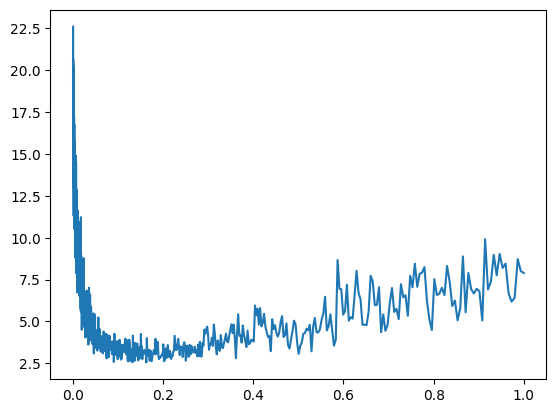

In [197]:
plt.plot(lri,lossi)

In [146]:
                    #*****why use cross_entropy******: 
#when the logist val is very high in pos .. the exp goes inf and prob becomes nan 
#so to overcome this cross_entopy subtract logist based on the hight val presnet in the tensor 
# logist=torch.tensor([-5,3,0,100]) -100 
# count=logist.exp()
# prob=count/count.sum()
# prob

In [181]:
emb=C[X] 
h=torch.tanh(emb.view(-1,6) @w1 +b1) #32 , 100 
logist=h@w2+b2
loss=F.cross_entropy(logist,Y)
loss

tensor(2.5611, grad_fn=<NllLossBackward0>)